<a href="https://colab.research.google.com/github/Foll0wTh3Wh1teRabbit/ML/blob/master/NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Нейро́нная сеть  — математическая модель, а также её программное или аппаратное воплощение, построенная по принципу организации и функционирования биологических нейронных сетей — сетей нервных клеток живого организма. Это понятие возникло при изучении процессов, протекающих в мозге, и при попытке смоделировать эти процессы. Первой такой попыткой были нейронные сети У. Маккалока и У. Питтса. После разработки алгоритмов обучения получаемые модели стали использовать в практических целях: в задачах прогнозирования, для распознавания образов, в задачах управления и др.

ИНС представляет собой систему соединённых и взаимодействующих между собой простых процессоров (искусственных нейронов). Такие процессоры обычно довольно просты (особенно в сравнении с процессорами, используемыми в персональных компьютерах). Каждый процессор подобной сети имеет дело только с сигналами, которые он периодически получает, и сигналами, которые он периодически посылает другим процессорам. И, тем не менее, будучи соединёнными в достаточно большую сеть с управляемым взаимодействием, такие по отдельности простые процессоры вместе способны выполнять довольно сложные задачи.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_digits
from sklearn import preprocessing

from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, mean_absolute_error, mean_squared_error

**Neural Network Regression**

In [ ]:
houses = fetch_california_housing()

df = pd.DataFrame(data=houses.data, columns=houses.feature_names)
df["target"] = houses.target

df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
X, y = fetch_california_housing(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

Попробуем без всякого проектирования архитектуры сети, лишь задав максимальное число итераций, обучить сеть

In [ ]:
nnr = MLPRegressor(max_iter=30000).fit(X_train, y_train)

In [ ]:
y_pred = nnr.predict(X_test)

print("MAE, Neural Network:", mean_absolute_error(y_test, y_pred))
print("MSE, Neural Network:", mean_squared_error(y_test, y_pred))
print("RMSE, Neural Network:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE, Neural Network: 0.7369571032722149
MSE, Neural Network: 0.9340976475365527
RMSE, Neural Network: 0.9664872723096527


Сравним с линейной регрессией и KNN

In [ ]:
lr = LinearRegression().fit(X_train, y_train)
knnReg = KNeighborsRegressor().fit(X_train, y_train)

In [ ]:
y_pred = lr.predict(X_test)

print("MAE, Linear Regression:", mean_absolute_error(y_test, y_pred))
print("MSE, Linear Regression:", mean_squared_error(y_test, y_pred))
print("RMSE, Linear Regression:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE, Linear Regression: 0.5319994026399221
MSE, Linear Regression: 0.5193396292118705
RMSE, Linear Regression: 0.7206522248712416


In [ ]:
y_pred = knnReg.predict(X_test)

print("MAE, KNN:", mean_absolute_error(y_test, y_pred))
print("MSE, KNN:", mean_squared_error(y_test, y_pred))
print("RMSE, KNN:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE, KNN: 0.8104557054263566
MSE, KNN: 1.1074797469383004
RMSE, KNN: 1.052368636428462


Видим не самую хорошую картину...
Теперь попробуем более детально продумать обучение сети и ее архитектуру

In [ ]:
nnr_new = MLPRegressor(max_iter=60000, hidden_layer_sizes=(256, 16), activation='tanh', random_state=144).fit(X_train, y_train)

In [ ]:
y_pred = nnr_new.predict(X_test)

print("MAE, New Neural Network:", mean_absolute_error(y_test, y_pred))
print("MSE, New Neural Network:", mean_squared_error(y_test, y_pred))
print("RMSE, New Neural Network:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE, New Neural Network: 0.5231042350411433
MSE, New Neural Network: 0.479077770755228
RMSE, New Neural Network: 0.6921544414039601


**Neural Network Classifier**

In [ ]:
digits = load_digits()

df = pd.DataFrame(data=digits.data, columns=digits.feature_names)
df["target"] = digits.target

df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [ ]:
X, y = load_digits(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

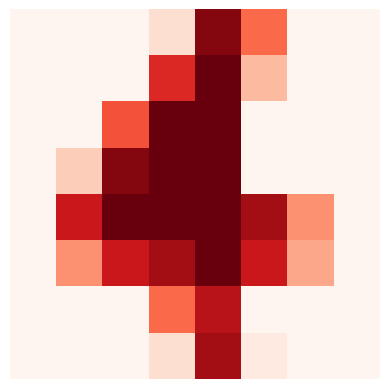

In [ ]:
some_digit_data = X[228]
some_digit_image = some_digit_data.reshape(8, 8)

plt.imshow(some_digit_image, cmap=plt.cm.Reds)
plt.axis("off")
plt.show()

In [ ]:
y[228]

4

Пойдем по аналогичной схеме: втупую проставим число итераций

In [ ]:
nnc = MLPClassifier(max_iter=10000).fit(X_train, y_train)

In [ ]:
nnc.predict([some_digit_data])

array([4])

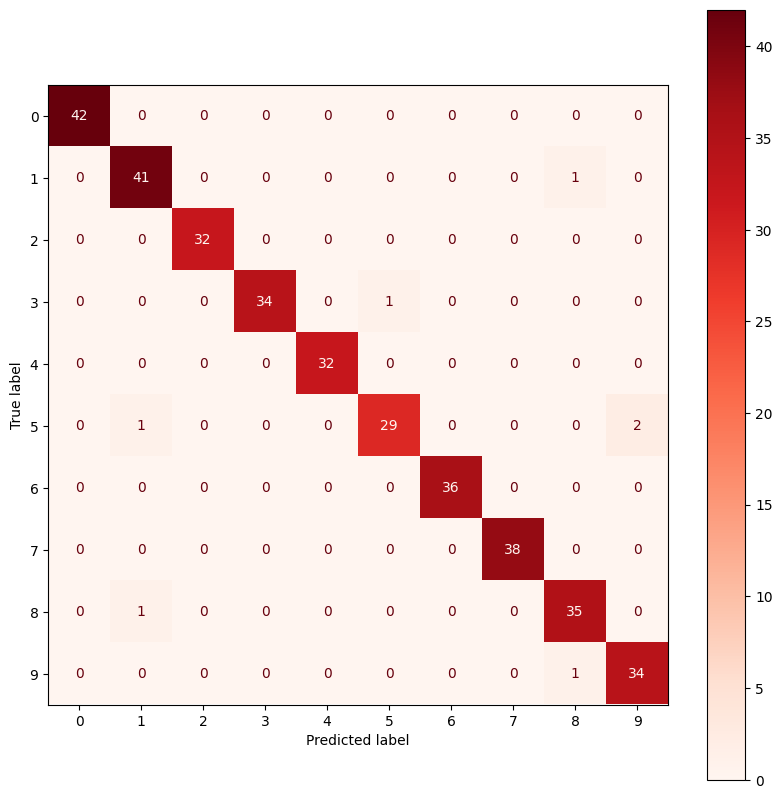

In [ ]:
y_pred = nnc.predict(X_test)

cf_mat = confusion_matrix(y_test, y_pred)

cm_fig, cm_ax = plt.subplots(figsize=(10, 10))
cf_mat_disp = ConfusionMatrixDisplay(cf_mat)
cf_mat_disp.plot(ax=cm_ax, cmap=plt.cm.Reds)

plt.show()

In [ ]:
print("Accuracy, Neural Network:", accuracy_score(y_test, y_pred))
print("Precision, Neural Network:", precision_score(y_test, y_pred, average='macro'))
print("Recall, Neural Network:", recall_score(y_test, y_pred, average='macro'))

Accuracy, Neural Network: 0.9805555555555555
Precision, Neural Network: 0.981054542915008
Recall, Neural Network: 0.979751984126984


Сравним с логистической регрессией и KNN

In [ ]:
lr = LogisticRegression(max_iter=30000).fit(X_train, y_train)
knnCl = KNeighborsClassifier().fit(X_train, y_train)

In [ ]:
y_pred = lr.predict(X_test)

print("Accuracy, Logistic Regression:", accuracy_score(y_test, y_pred))
print("Precision, Logistic Regression:", precision_score(y_test, y_pred, average='macro'))
print("Recall, Logistic Regression:", recall_score(y_test, y_pred, average='macro'))

Accuracy, Logistic Regression: 0.9694444444444444
Precision, Logistic Regression: 0.9695729181213052
Recall, Logistic Regression: 0.9684398496240603


In [ ]:
y_pred = knnCl.predict(X_test)

print("Accuracy, KNN:", accuracy_score(y_test, y_pred))
print("Precision, KNN:", precision_score(y_test, y_pred, average='macro'))
print("Recall, KNN:", recall_score(y_test, y_pred, average='macro'))

Accuracy, KNN: 0.9888888888888889
Precision, KNN: 0.9895547604849929
Recall, KNN: 0.9883829365079364


Метрики нейронки (даже при таком подходе) получились хорошие, но попробуем их улучшить

In [ ]:
nnc_new = MLPClassifier(max_iter=40000, hidden_layer_sizes=(1000, 100, 10), activation='logistic', random_state=144).fit(X_train, y_train)

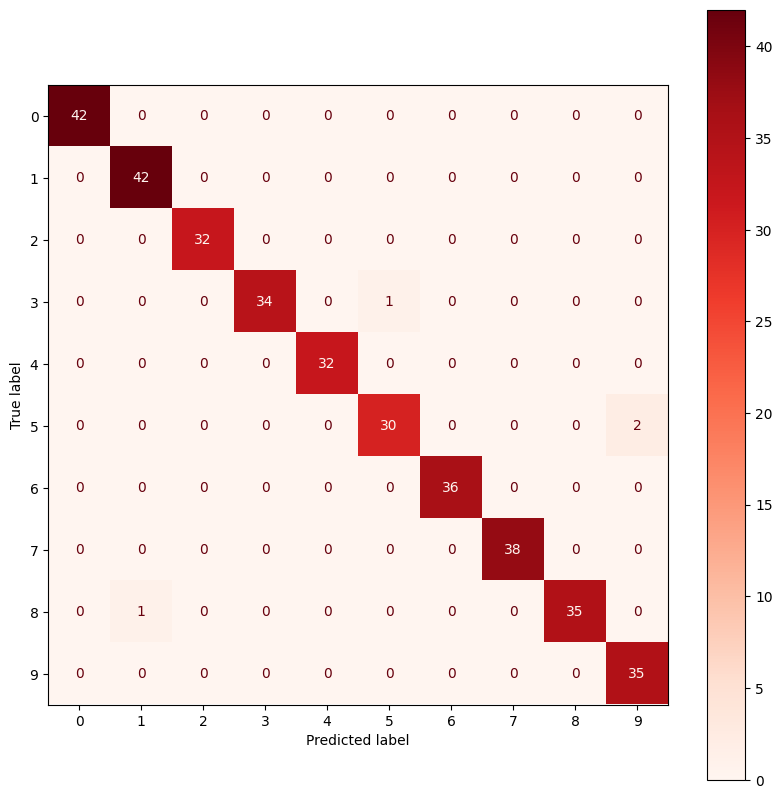

In [ ]:
y_pred = nnc_new.predict(X_test)

cf_mat = confusion_matrix(y_test, y_pred)

cm_fig, cm_ax = plt.subplots(figsize=(10, 10))
cf_mat_disp = ConfusionMatrixDisplay(cf_mat)
cf_mat_disp.plot(ax=cm_ax, cmap=plt.cm.Reds)

plt.show()

In [ ]:
print("Accuracy, New Neural Network:", accuracy_score(y_test, y_pred))
print("Precision, New Neural Network:", precision_score(y_test, y_pred, average='macro'))
print("Recall, New Neural Network:", recall_score(y_test, y_pred, average='macro'))

Accuracy, New Neural Network: 0.9888888888888889
Precision, New Neural Network: 0.9890432067476327
Recall, New Neural Network: 0.9881150793650793
